# Uber Data Analysis

In [93]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

import os 
for dirname, _,filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

# Data Understanding

In [96]:
df=pd.read_csv('UberDataset.csv')
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [100]:
df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

# Data Cleaning

In [103]:
df['PURPOSE']=df['PURPOSE'].fillna("UNKNOWN")
df.dropna(inplace=True)

In [105]:
df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

# Data Preprocessing

In [108]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')



df['TIME_DAY']=df['START_DATE'].apply(lambda i : i.hour)
df['TIME_OF_DAY']=df['START_DATE'].apply(lambda i : i.hour)
df['TIME_OF_DAY']=pd.cut(x=df['TIME_OF_DAY'], bins=[0,6,11,17,21,24],\
                        labels=['Night','Morning','After noon','Evening','Night'],ordered=False)

df['MONTH_OF_THE_RIDE']=df['START_DATE'].apply(lambda i :i.month)
month_label={1.0:'Jan',2.0:'Feb',3.0:'Mar',4.0:'April',5.0:'May',6.0:'June',7.0:'July',8.0:'Aug',9.0:'Sep',10.0:'Oct',11.0:'Nov',12.0:'Dec'}
df['MONTH_OF_THE_RIDE']=df['MONTH_OF_THE_RIDE'].map(month_label)

df['DAY_OF_THE_RIDE']=df['START_DATE'].apply(lambda i:i.weekday())
day_label={0:'Mon',1:'Tues',2:'Wed',3:'Thus',4:'Fri',5:'Sat',6:'Sun'}

df['DAY_OF_THE_RIDE']=df['DAY_OF_THE_RIDE'].map(day_label)

df['DURATION_OF_THE_RIDE'] = (df['END_DATE'] - df['START_DATE']) / pd.Timedelta(minutes=1)
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,TIME_DAY,TIME_OF_DAY,MONTH_OF_THE_RIDE,DAY_OF_THE_RIDE,DURATION_OF_THE_RIDE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.0,Evening,Jan,Fri,6.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,UNKNOWN,1.0,Night,Jan,Sat,12.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.0,Evening,Jan,Sat,13.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.0,After noon,Jan,Tues,14.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.0,After noon,Jan,Wed,67.0


# Data Exploration

In [111]:
df.describe()

,START_DATE,END_DATE,MILES,TIME_DAY,DURATION_OF_THE_RIDE
count,421,420,1155.000000,421.000000,420.000000
mean,2016-07-01 12:31:09.976247040,2016-07-01 12:11:10.142857216,10.566840,14.988124,19.326190
min,2016-01-01 21:11:00,2016-01-01 21:17:00,0.500000,0.000000,0.000000
25%,2016-04-01 13:43:00,2016-03-27 15:10:00,2.900000,12.000000,9.000000
50%,2016-07-04 18:23:00,2016-07-04 18:19:00,6.000000,15.000000,15.000000
75%,2016-10-10 17:22:00,2016-10-10 17:39:15,10.400000,18.000000,22.250000
max,2016-12-12 20:48:00,2016-12-12 20:57:00,310.300000,23.000000,178.000000
std,NaN,NaN,21.579106,4.668777,19.155582


In [113]:
print('Min Timestamp in START_TIME is -{}'.format(df['START_DATE'].min()))
print('Max Timestamp in START_TIME is -{}'.format(df['START_DATE'].max()))

Min Timestamp in START_TIME is -2016-01-01 21:11:00
Max Timestamp in START_TIME is -2016-12-12 20:48:00


In [115]:
print("Total number of unique categories in CATEGORY -{}".format(df['CATEGORY'].nunique()))
print("Total number of unique categories in PURPOSE -{}".format(df['PURPOSE'].nunique()))
print("Total number of unique location in START -{}".format(df['START'].nunique()))
print("Total number of unique location in STOP -{}".format(df['STOP'].nunique()))

Total number of unique categories in CATEGORY -2
Total number of unique categories in PURPOSE -11
Total number of unique location in START -177
Total number of unique location in STOP -188


# Data Visualization

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2669045125.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='CATEGORY',ax=axes[0,0],palette=custom_colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2669045125.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(data=df,x='CATEGORY',ax=axes[0,0],palette=custom_colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2669045125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='PURPOSE',ax=axes[1,0],palette=custom_colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2669045125.py:12: UserWarning: 
The palette list has fewer values

AttributeError: 'Axes' object has no attribute 'trick_params'

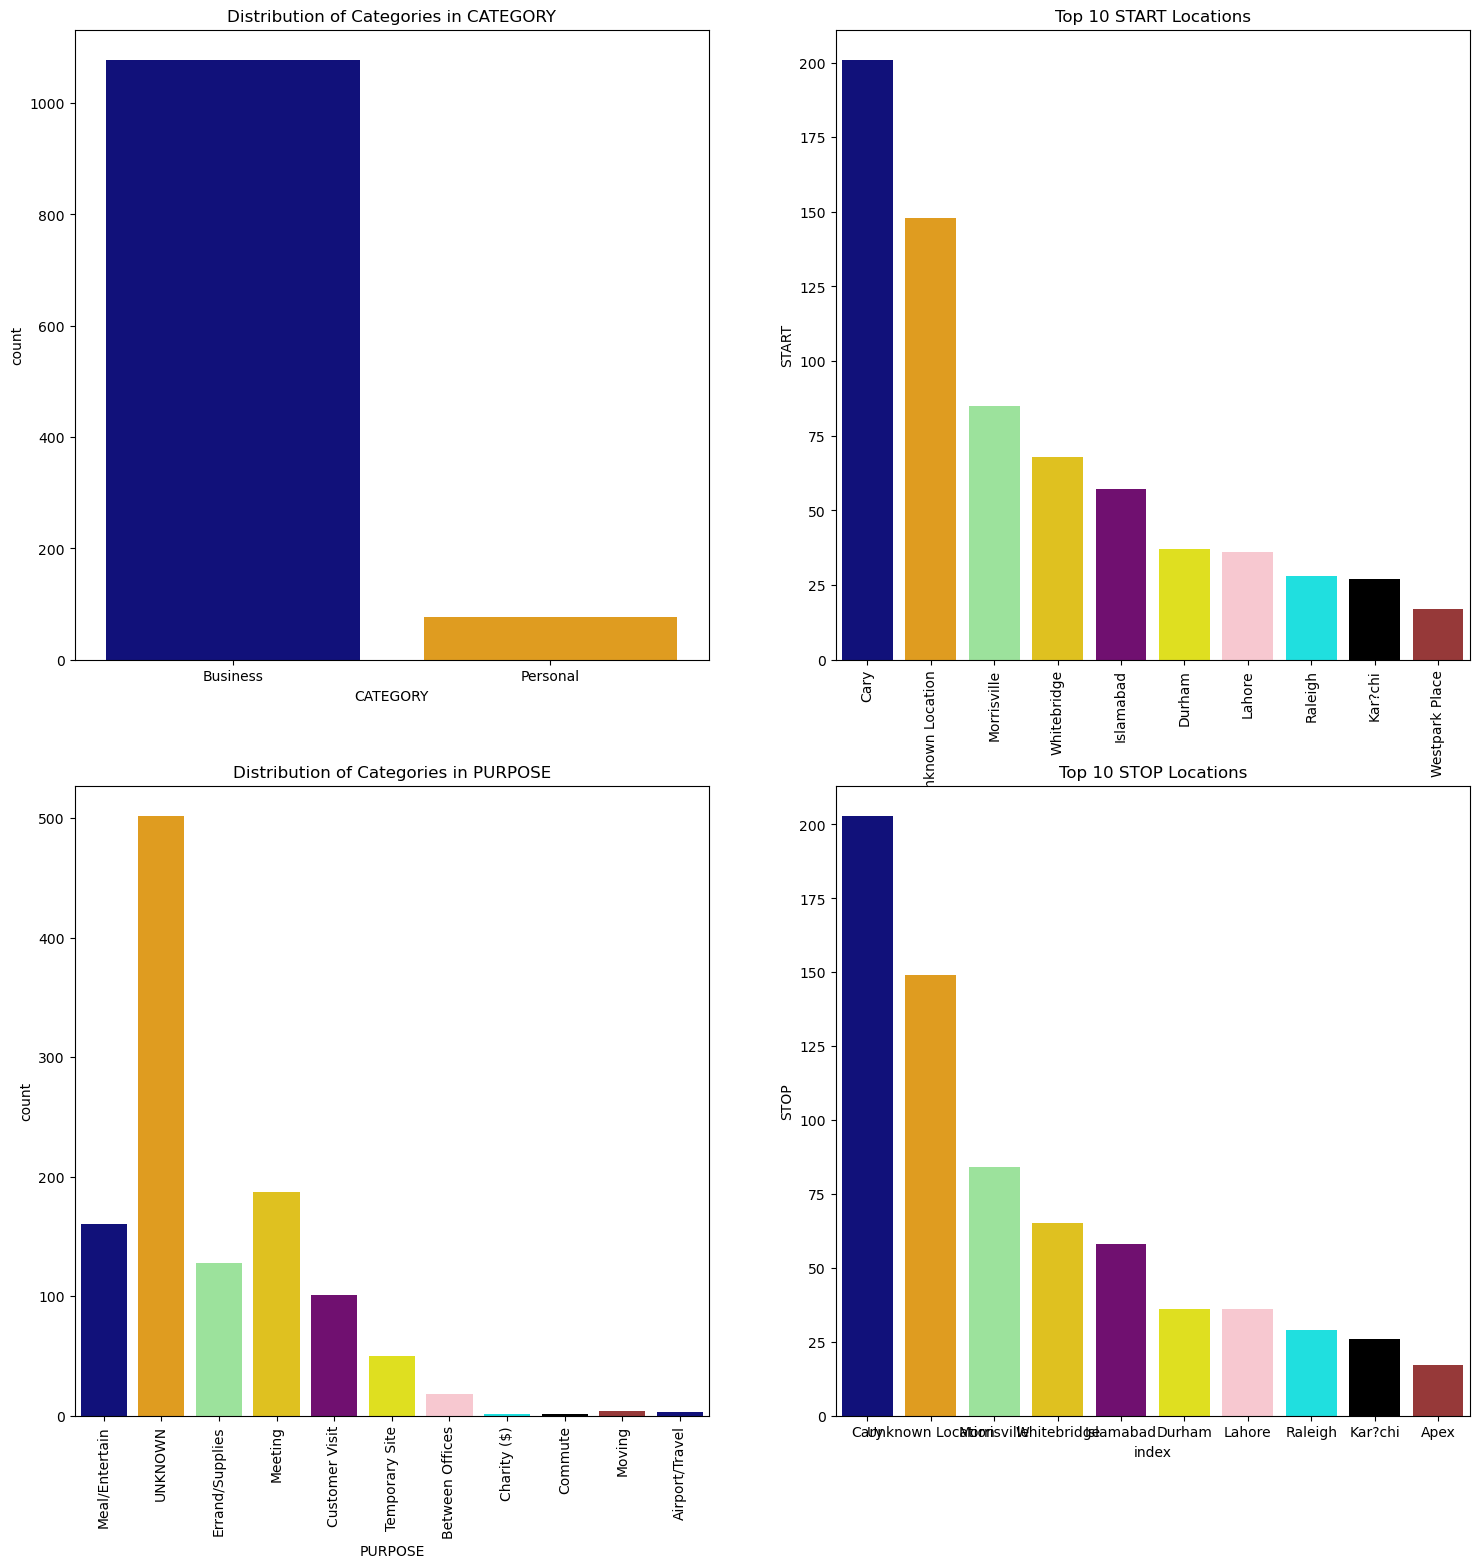

In [162]:
df['CATEGORY']=df['CATEGORY'].astype('category')

custom_colors=['#00008B','orange','#90EE90','#FFD700','purple','yellow','pink','cyan','black','brown']

fig,axes=plt.subplots(2,2,figsize=(18,18))


sns.countplot(data=df,x='CATEGORY',ax=axes[0,0],palette=custom_colors)
axes[0,0].set_title('Distribution of Categories in CATEGORY')


sns.countplot(data=df,x='PURPOSE',ax=axes[1,0],palette=custom_colors)
axes[1,0].set_title('Distribution of Categories in PURPOSE')
axes[1,0].tick_params(axis='x',rotation=90)



temp=df['START'].value_counts().nlargest(10).reset_index()
temp.columns=['index','START']
sns.barplot(data=temp,x='index',y='START',ax=axes[0,1],palette=custom_colors)
axes[0,1].set_title('Top 10 START Locations')
axes[0,1].tick_params(axis='x',rotation=90)


temp=df['STOP'].value_counts().nlargest(10).reset_index()
temp.columns=['index','STOP']
sns.barplot(data=temp,x='index',y='STOP',ax=axes[1,1],palette=custom_colors)
axes[1,1].set_title('Top 10 STOP Locations')
axes[1,1].trick_params(axis='x',rotation=90)



plt.tight_layout()
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\3405849186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='TIME_OF_DAY',palette=custom_colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\3405849186.py:3: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(data=df,x='TIME_OF_DAY',palette=custom_colors)


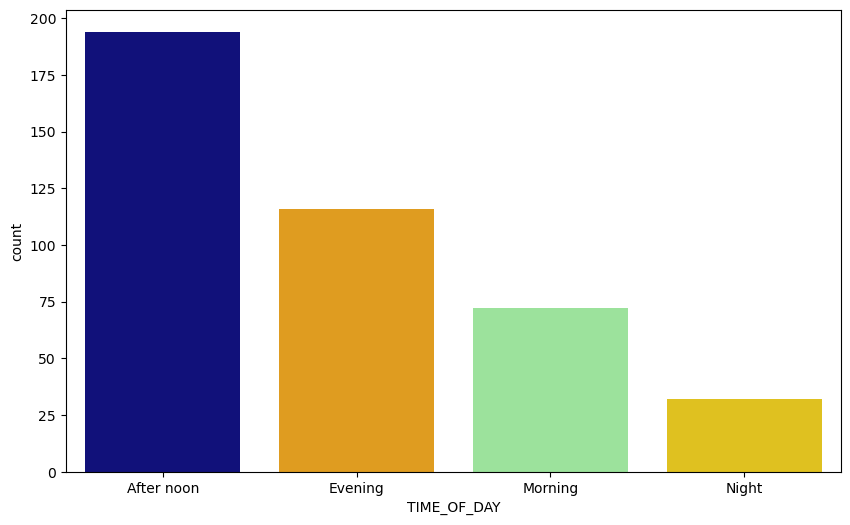

In [148]:
df['TIME_OF_DAY']=df['TIME_OF_DAY'].astype('category')
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='TIME_OF_DAY',palette=custom_colors)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\4290112938.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='MONTH_OF_THE_RIDE',palette=colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\4290112938.py:5: UserWarning: 
The palette list has fewer values (8) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df,x='MONTH_OF_THE_RIDE',palette=colors)


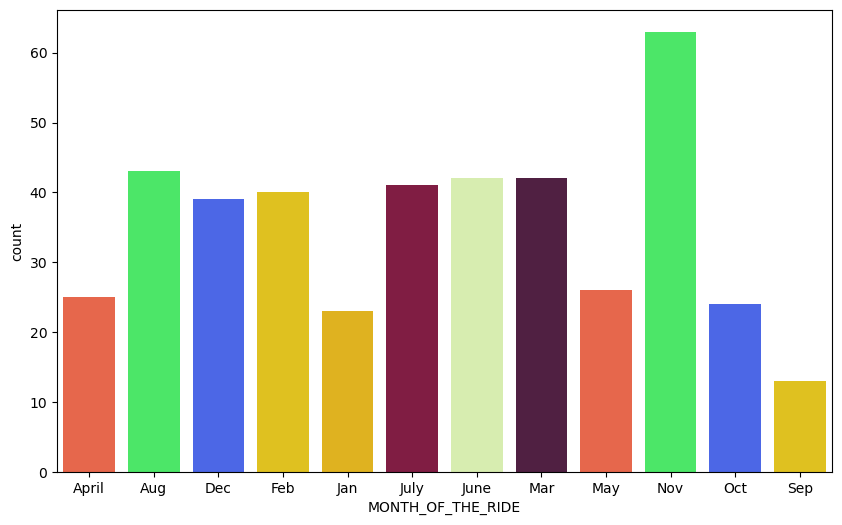

In [170]:
colors=['#FF5733', '#33FF57', '#3357FF', '#FFD700', '#FFC300', '#900C3F', '#DAF7A6', '#581845']
df['MONTH_OF_THE_RIDE']=df['MONTH_OF_THE_RIDE'].astype('category')

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='MONTH_OF_THE_RIDE',palette=colors)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\1252662307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='DAY_OF_THE_RIDE',palette=custom_colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\1252662307.py:2: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.countplot(data=df,x='DAY_OF_THE_RIDE',palette=custom_colors)


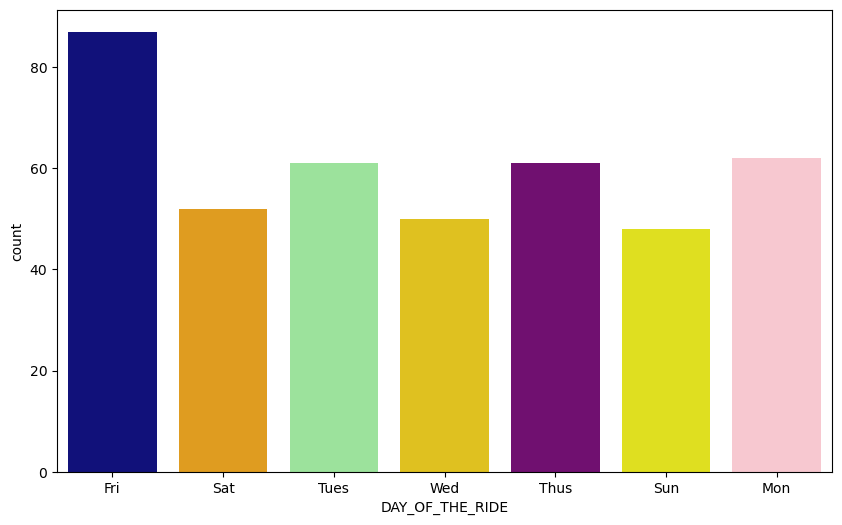

In [154]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='DAY_OF_THE_RIDE',palette=custom_colors)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2713121415.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp=df.groupby('MONTH_OF_THE_RIDE')['TIME_DAY'].mean().reset_index()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2713121415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MONTH_OF_THE_RIDE',y='TIME_DAY',data=temp,palette=colors)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22088\2713121415.py:3: UserWarning: 
The palette list has fewer values (8) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='MONTH_OF_THE_RIDE',y='TIME_DAY',data=temp,palette=colors)


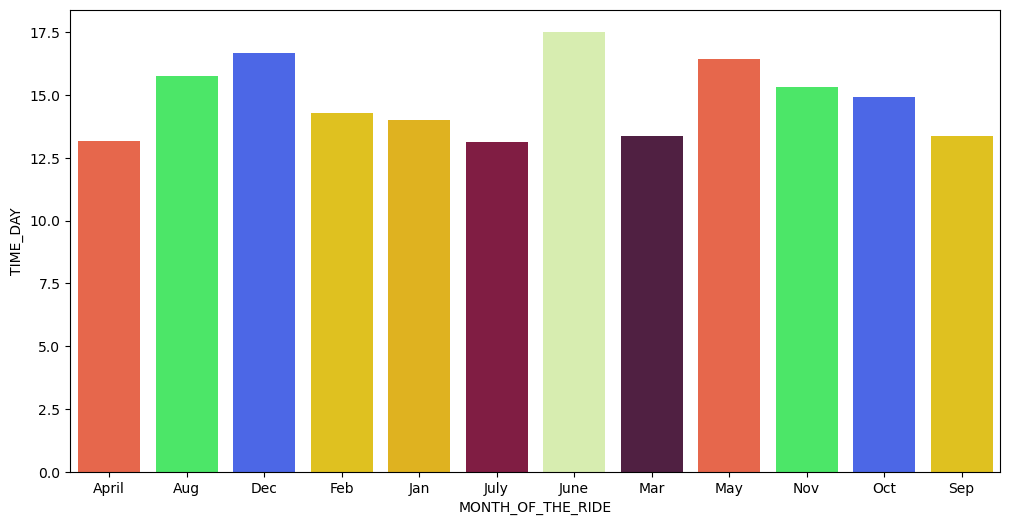

In [172]:
plt.figure(figsize=(12,6))
temp=df.groupby('MONTH_OF_THE_RIDE')['TIME_DAY'].mean().reset_index()
sns.barplot(x='MONTH_OF_THE_RIDE',y='TIME_DAY',data=temp,palette=colors)
plt.show()

In [174]:
df.to_csv('cleaning_uber_data')